In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [9]:
from langgraph.graph import START, END
class InputState(TypedDict):
    user_input: str
    
class OutputState(TypedDict):
    response: str
    
    
class PrivateState(TypedDict):
    bar: str
    
class OverallState(TypedDict):
    foo: str
    user_input: str
    graph_output: str
    
def node1(state: InputState) -> OverallState:
    return {"foo": state["user_input"] + " name"}

def node2(state: OverallState) -> PrivateState:
    return {"bar": state["foo"] + " is"}

def node3(state: PrivateState) -> OutputState:
    return {"response": state["bar"] + " Goldy"}


workflow = StateGraph(OverallState, output=OutputState, input=InputState)

workflow.add_node("node1", node1)
workflow.add_node("node2", node2)
workflow.add_node("node3", node3)

# adding edges
workflow.add_edge(START, "node1")
workflow.add_edge("node1", "node2")
workflow.add_edge("node2", "node3")
workflow.add_edge("node3", END)



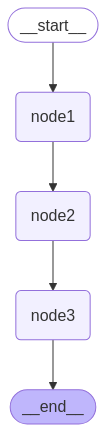

In [11]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [12]:
graph = workflow.compile()
graph.invoke({"user_input": "my"})

{'response': 'my name is Goldy'}

## We pass state: InputState as the input schema to node_1. But, we write out to foo, a channel in OverallState. How can we write out to a state channel that is not included in the input schema? 

It's because a node can write to any state channel in the graph state.
The graph state is the union of the state channels defined at initialization, which includes overallstate and the filters inputstate and outputstate


## We initialize the graph with StateGraph(OverallState,input=InputState,output=OutputState). So, how can we write to PrivateState in node_2? How does the graph gain access to this schema if it was not passed in the StateGraph initialization? 

We can do this because nodes can also declare additional state channels as long as the state schema definition exists. in this case the privatestate schema is deined so we can add bar as a new state channels in the graph and write to it. 

In [22]:
class x(TypedDict):
    a: str
    b: str
    c: str
    print("i cam called")
    

i cam called


In [20]:
def node_x(state: x) ->x:
    return {"a": state["a"], 
            "b": "goldy",}

graph = StateGraph(x)
graph.add_node("node_x", node_x)
graph.add_edge(START, "node_x")
graph.add_edge("node_x", END)

graph = graph.compile()
graph.invoke({"a": "my"})

{'a': 'my', 'b': 'goldy'}